In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from context_flux_no.nn.utils import num_parameters
from context_flux_no.simulations.pde import Burgers1D
from context_flux_no.waveforms.fourier import TruncatedFourier1D


jax.config.update("jax_enable_x64", True)

INFO:2025-10-03 19:46:09,476:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-10-03 19:46:09,476 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


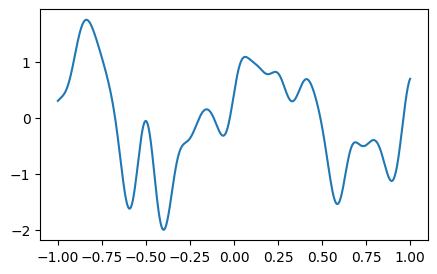

In [2]:
import matplotlib.pyplot as plt
from context_flux_no.waveforms.grf import (
    GaussianCov,
    generate_circulant_embedding_method_1d,
)


x = jnp.linspace(-1, 1, 1024)
u0 = generate_circulant_embedding_method_1d(
    1024, x[1] - x[0], GaussianCov(0.1), key=jax.random.key(1)
)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0)

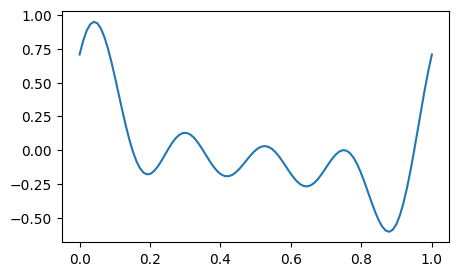

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [4]:
from context_flux_no.waveforms.grf import GaussianRandomField1D


grf = GaussianRandomField1D(GaussianCov(0.1))
u0_func = lambda x_: grf.sample(x_, key=jax.random.key(0))
burgers = Burgers1D()
# u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)

sol = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 1024, (0.0, 0.2), 1000, "periodic")

2025-10-03 19:46:31,749 INFO CLAW: Solution 0 computed for time t=0.000000
2025-10-03 19:46:31,750 INFO CLAW: Solution 1 computed for time t=0.000200
2025-10-03 19:46:31,751 INFO CLAW: Solution 2 computed for time t=0.000400
2025-10-03 19:46:31,752 INFO CLAW: Solution 3 computed for time t=0.000600
2025-10-03 19:46:31,753 INFO CLAW: Solution 4 computed for time t=0.000800
2025-10-03 19:46:31,754 INFO CLAW: Solution 5 computed for time t=0.001000
2025-10-03 19:46:31,755 INFO CLAW: Solution 6 computed for time t=0.001200
2025-10-03 19:46:31,756 INFO CLAW: Solution 7 computed for time t=0.001400
2025-10-03 19:46:31,757 INFO CLAW: Solution 8 computed for time t=0.001600
2025-10-03 19:46:31,758 INFO CLAW: Solution 9 computed for time t=0.001800
2025-10-03 19:46:31,759 INFO CLAW: Solution 10 computed for time t=0.002000
2025-10-03 19:46:31,760 INFO CLAW: Solution 11 computed for time t=0.002200
2025-10-03 19:46:31,761 INFO CLAW: Solution 12 computed for time t=0.002400
2025-10-03 19:46:31,76

In [5]:
sol

<xarray.DataArray (sample: 1, t: 1001, dim: 1, x: 1024)> Size: 8MB
array([[[[1.21378088, 1.19963657, 1.18498591, ..., 1.32041834,
          1.29743573, 1.27372028]],

        [[1.2279521 , 1.20233106, 1.188598  , ..., 1.32653413,
          1.30364253, 1.28092611]],

        [[1.24175449, 1.20713213, 1.19162503, ..., 1.33265123,
          1.3098118 , 1.28775444]],

        ...,

        [[1.38702732, 1.30829606, 1.2756839 , ..., 1.52023119,
          1.50770122, 1.46785184]],

        [[1.41310336, 1.32654375, 1.28091222, ..., 1.52165427,
          1.51305722, 1.48349585]],

        [[1.43747482, 1.34883937, 1.28897938, ..., 1.52260484,
          1.51677833, 1.49549356]]]], shape=(1, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.0002 0.0004 0.0006 ... 0.1996 0.1998 0.2
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

In [8]:
sol.shape

(1, 1001, 1, 1024)

In [6]:
import logging


logger = logging.getLogger("pyclaw")
logger.__dict__

{'filters': [],
 'name': 'pyclaw',
 'level': 20,
 'parent': <RootLogger root (INFO)>,
 'propagate': 1,
 'handlers': [<FileHandler /home/jhko725/projects/CONTEXT_FLUX_NO/notebooks/data_generation/pyclaw.log (NOTSET)>,
  <StreamHandler stdout (INFO)>],
 'disabled': 0,
 '_cache': {},
 'manager': <logging.Manager at 0x1488c1fd29c0>}

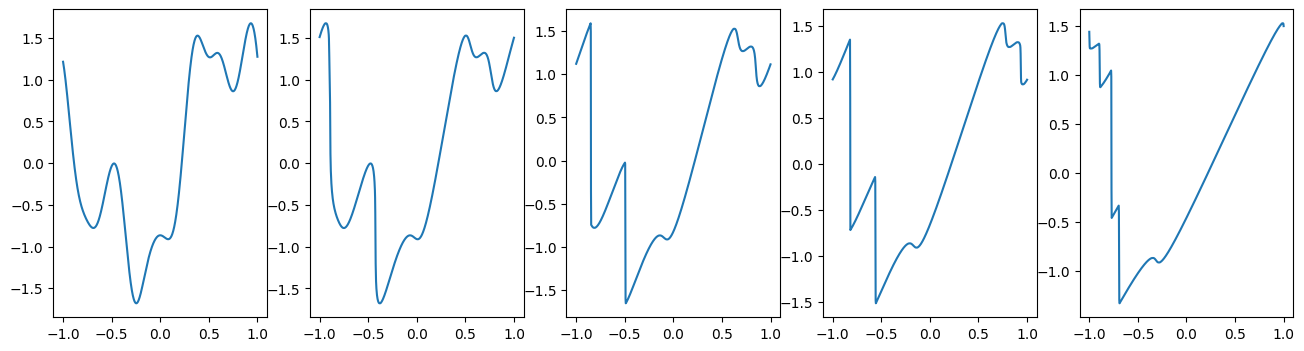

In [14]:
t_vals = (0, 200, 400, 600, 1000)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(x, sol.isel(sample=0, t=t_i, dim=0))

In [ ]:
data_array = xr.DataArray(
    np.expand_dims(u, axis=0),
    coords={
        "t": t,
        "x": x,
        "dim": [
            "u",
        ],
        "nu": ("sample", [0.0]),
    },
    dims=["sample", "t", "dim", "x"],
)

In [9]:
data_array

<xarray.DataArray (sample: 1, t: 1001, dim: 1, x: 1024)> Size: 8MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]]], shape=(1, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.006 0.012 0.018 ... 5.982 5.988 5.994 6.0
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 8B 0.0
Dimensions without coordinates: sample

In [10]:
xr.concat((data_array, data_array), "sample")

<xarray.DataArray (sample: 2, t: 1001, dim: 1, x: 1024)> Size: 16MB
array([[[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]],


       [[[0.71250518, 0.7231502 , 0.73358954, ..., 0.67937639,
          0.69061415, 0.70165847]],

        [[0.66683561, 0.67753383, 0.6880781 , ..., 0.63385509,
          0.64499243, 0.65598721]],

        [[0.62443636, 0.63496599, 0.64538165, ..., 0.59219562,
          0.603048  , 0.61379597]],

        ...,

        [[0.00833087, 0.00849227, 0.00865368, ..., 0.00784664,
          0.00800805, 0.00816946]],

        [[0.00832261, 0.00848386, 0.0086451 , ..., 0.00783887,
          0.00800012, 0.00816137]],

        [[0.00831438, 0.00847546, 0.00863655, ..., 0.00783111,
          0.0079922 , 0.00815329]]]], shape=(2, 1001, 1, 1024))
Coordinates:
  * t        (t) float64 8kB 0.0 0.006 0.012 0.018 ... 5.982 5.988 5.994 6.0
  * x        (x) float64 8kB 0.0004883 0.001465 0.002441 ... 0.9985 0.9995
  * dim      (dim) <U1 4B 'u'
    nu       (sample) float64 16B 0.0 0.0
Dimensions without coordinates: sample

In [11]:
data_array.coords["nu"].dims

('sample',)

In [12]:
from context_flux_no.models.fluxfno import FluxFNO1D


model = FluxFNO1D(
    data_dim=1,
    lift_dim=64,
    depth=4,
    frequency_modes=8,
    stencil_size=2,
    key=jax.random.key(0),
)

u = jnp.asarray(data_array[0, 0])
u.shape

(1, 1024)

In [13]:
u_out = model(u, 6.0 / 1000, 1.0 / 1024)

2025-09-10 18:29:37.782885: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-10 18:29:38.949871: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.167130155s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

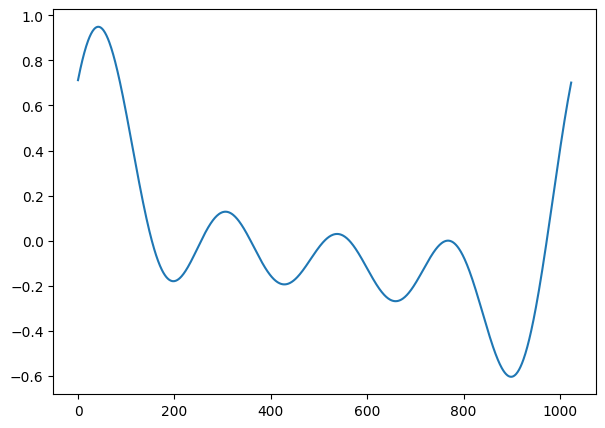

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(u_out[0])

In [25]:
num_parameters(model)

165313

In [ ]:
# model = FNO1D(
#     data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
# )


TypeError: FNO1D.__init__() got an unexpected keyword argument 'data_dim'

In [13]:
out = fno(sol[0])

2025-07-29 01:36:37.117089: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-29 01:36:40.975288: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.858323399s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1,64,1024]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), 

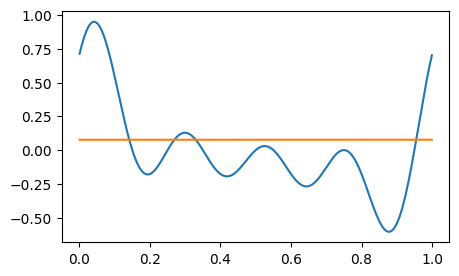

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [15]:
sol[1:501].shape

(500, 1, 1024)

In [14]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model, in_axes=(0, None, None))(
        u0, 6.0 / 1000, 1.0 / 1024
    )
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [15]:
sol = jnp.asarray(data_array[0])
sol.shape

(1001, 1, 1024)

In [16]:
max_epochs = 1000
loss_history = []
for i in range(max_epochs):
    model, opt_state, loss = make_step(model, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.0005161681187226657
Epoch = 1: Loss = 0.0005158406756265919
Epoch = 2: Loss = 0.0005154977784066621
Epoch = 3: Loss = 0.000515122003697004
Epoch = 4: Loss = 0.0005146923125998957
Epoch = 5: Loss = 0.0005141822013877835
Epoch = 6: Loss = 0.0005135569455099677
Epoch = 7: Loss = 0.0005127694222764438
Epoch = 8: Loss = 0.0005117537665198371
Epoch = 9: Loss = 0.0005104156859939352
Epoch = 10: Loss = 0.000508617560278349
Epoch = 11: Loss = 0.000506155460126932
Epoch = 12: Loss = 0.0005027239956069132
Epoch = 13: Loss = 0.0004978638331798654
Epoch = 14: Loss = 0.0004908871757632568
Epoch = 15: Loss = 0.000480781879565681
Epoch = 16: Loss = 0.0004661123852537025
Epoch = 17: Loss = 0.000444979654092726
Epoch = 18: Loss = 0.0004152048530624698
Epoch = 19: Loss = 0.00037514740788685184
Epoch = 20: Loss = 0.000326232207526968
Epoch = 21: Loss = 0.000280084890444387
Epoch = 22: Loss = 0.0002717303952599079
Epoch = 23: Loss = 0.0002992213077430029
Epoch = 24: Loss = 0.00028470263

Text(0, 0.5, 'Train loss')

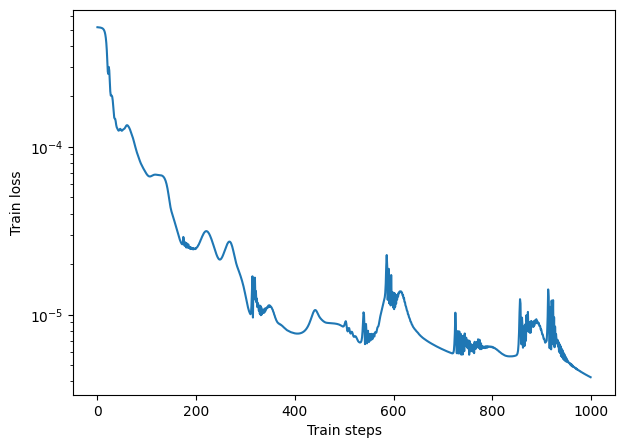

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Train steps")
ax.set_ylabel("Train loss")

In [27]:
float(data_array.t[1] - data_array.t[0])

0.006

Text(0, 0.5, '$u_{pred}-u_{data}$')

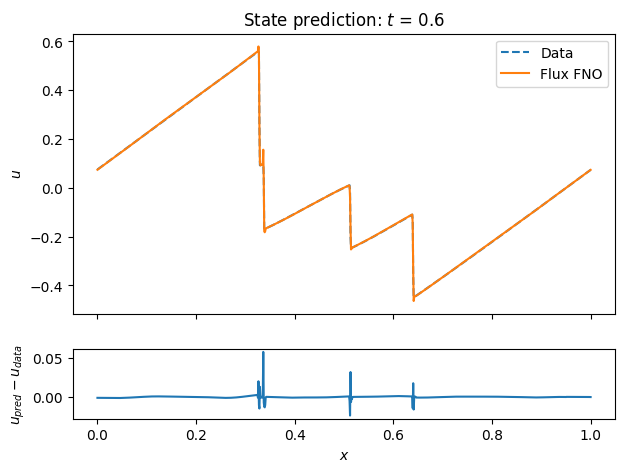

In [34]:
time_idx = 100
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=(4, 1))
u_data = sol[time_idx + 1][0]
u_pred = model(sol[time_idx], 6.0 / 1000, 1.0 / 1024)[0]
axes[0].plot(data_array.x, u_data, "--", label="Data")
axes[0].plot(data_array.x, u_pred, label="Flux FNO")
axes[0].legend()

axes[0].set_ylabel("$u$")
axes[0].set_title(
    f"State prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)
axes[1].plot(data_array.x, u_pred - u_data)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u_{pred}-u_{data}$")

Text(0.5, 1.0, 'Flux prediction: $t$ = 0.6')

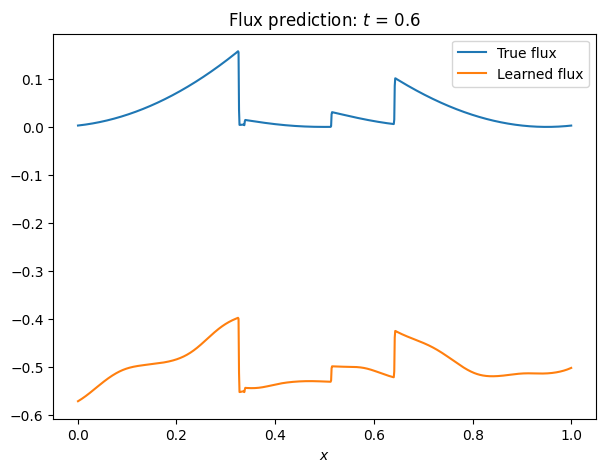

In [39]:
time_idx = 100
f_pred = model.physical_flux(sol[time_idx])
f_true = 0.5 * sol[time_idx] ** 2
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(data_array.x, f_true[0], label="True flux")
ax.plot(data_array.x, f_pred[0], label="Learned flux")
ax.legend()
ax.set_xlabel("$x$")
ax.set_title(
    f"Flux prediction: $t$ = {time_idx * float(data_array.t[1] - data_array.t[0])}"
)